In [1]:
file_read = "001_fit"
file_write = "002_RMSE"

In [2]:
import polars as pl

df_train_val_preds = pl.read_parquet(f"{file_read}_train_val_preds.parquet")
df_test_preds = pl.read_parquet(f"{file_read}_test_preds.parquet")
df_coefs = pl.read_parquet(f"{file_read}_coefs.parquet")

In [3]:
column_group = "pyridone"
column_fix = "backbone"
column_target = "beta_av"
column_target_scaled = "beta_av_logit"
column_pred = f"{column_target}_pred"
column_pred_scaled = f"{column_target_scaled}_pred"

In [4]:
df_train_val_preds = df_train_val_preds.with_columns(
    (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
    (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
)

In [5]:
df_train_val_preds

pyridone_test,n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i32,i32,i64,i64,f64,f64,f64,f64
0,51,1,0,0.56851,0.313249,63.841924,57.7678
0,51,1,1,0.577178,0.505691,64.041771,62.379579
0,51,1,2,0.53889,0.388622,63.155406,59.595082
0,51,1,3,0.85113,0.412173,70.080418,60.160885
0,51,1,4,0.637598,0.43252,65.421028,60.647535
…,…,…,…,…,…,…,…
12,5,11,3,-0.486342,-0.505023,38.07556,37.636098
12,5,11,4,-0.441697,-0.530778,39.133657,37.033554
12,5,11,5,0.134649,-0.010665,53.361149,49.733387


In [6]:
import numpy as np

df_train_val_preds = (
    pl.DataFrame({f"{column_group}_test": np.arange(13)})
    .join(pl.DataFrame({"n_features": np.arange(51, 4, -1)}), how="cross")
    .join(pl.DataFrame({column_group: np.arange(13)}), how="cross")
    .join(pl.DataFrame({column_fix: [0, 1, 2, 3, 4, 5, 19, 20]}), how="cross")
    .filter(pl.col(f"{column_group}_test") != pl.col(column_group))
    .join(
        df_train_val_preds,
        on=[f"{column_group}_test", "n_features", column_group, column_fix],
        how="left",
        maintain_order="left"
    )
)

In [7]:
df_train_val_preds

pyridone_test,n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i64,i64,i64,i64,f64,f64,f64,f64
0,51,1,0,0.56851,0.313249,63.841924,57.7678
0,51,1,1,0.577178,0.505691,64.041771,62.379579
0,51,1,2,0.53889,0.388622,63.155406,59.595082
0,51,1,3,0.85113,0.412173,70.080418,60.160885
0,51,1,4,0.637598,0.43252,65.421028,60.647535
…,…,…,…,…,…,…,…
12,5,11,3,-0.486342,-0.505023,38.07556,37.636098
12,5,11,4,-0.441697,-0.530778,39.133657,37.033554
12,5,11,5,0.134649,-0.010665,53.361149,49.733387


In [8]:
df_train_val_preds = df_train_val_preds.with_columns(
    pl.col([column_target, column_pred])
    .forward_fill()
    .over([f"{column_group}_test", column_group, column_fix])
)

In [9]:
df_train_val_preds.filter(
    (pl.col("pyridone_test") == 0)
    & (pl.col("pyridone") == 1)
    & (pl.col("backbone") == 0)
)

pyridone_test,n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i64,i64,i64,i64,f64,f64,f64,f64
0,51,1,0,0.56851,0.313249,63.841924,57.7678
0,50,1,0,null,null,63.841924,57.7678
0,49,1,0,null,null,63.841924,57.7678
0,48,1,0,null,null,63.841924,57.7678
0,47,1,0,null,null,63.841924,57.7678
…,…,…,…,…,…,…,…
0,9,1,0,0.56851,0.389241,63.841924,59.609991
0,8,1,0,0.56851,0.29487,63.841924,57.318808
0,7,1,0,0.56851,0.259833,63.841924,56.459536


In [10]:
df_train_val_rmse = (
    df_train_val_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [11]:
df_train_val_rmse

n_features,beta_av_rmse
i64,f64
51,4.421704
50,4.421704
49,4.421704
48,4.421704
47,4.421704
…,…
9,4.494824
8,4.552691
7,4.742785


In [12]:
df_train_val_rmse_min = df_train_val_rmse.filter(
    pl.col(f"{column_target}_rmse") == pl.col(f"{column_target}_rmse").min()
)

In [13]:
df_train_val_rmse_min

n_features,beta_av_rmse
i64,f64
15,4.386938


In [14]:
n_features_min = df_train_val_rmse_min["n_features"][0]

In [15]:
df_test_preds = df_test_preds.with_columns(
    (100 / (1 + (-pl.col(column_target_scaled)).exp())).alias(column_target),
    (100 / (1 + (-pl.col(column_pred_scaled)).exp())).alias(column_pred),
)

In [16]:
df_test_preds = (
    pl.DataFrame({f"{column_group}_test": np.arange(13)})
    .join(pl.DataFrame({"n_features": np.arange(51, 4, -1)}), how="cross")
    .join(pl.DataFrame({column_fix: [0, 1, 2, 3, 4, 5, 19, 20]}), how="cross")
    .join(
        df_test_preds,
        on=[f"{column_group}_test", "n_features", column_fix],
        how="left",
        maintain_order="left"
    )
)

In [17]:
df_test_preds

pyridone_test,n_features,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i64,i64,i64,f64,f64,f64,f64
0,51,0,0.055549,0.154508,51.388357,53.855042
0,51,1,0.061619,0.03908,51.539999,50.976868
0,51,2,-0.086761,-0.006642,47.832328,49.833959
0,51,3,-0.086245,0.034357,47.845209,50.858843
0,51,4,-0.242775,0.031064,43.960253,50.776538
…,…,…,…,…,…,…
12,5,3,-0.155744,-0.230622,46.114252,44.259862
12,5,4,-0.010116,-0.246425,49.74711,43.870372
12,5,5,-0.04161,0.37933,48.959898,59.371142


In [18]:
df_test_preds = df_test_preds.with_columns(
    pl.col([column_target, column_pred])
    .forward_fill()
    .over([f"{column_group}_test", column_fix])
)

In [19]:
df_test_preds.filter(
    (pl.col("pyridone_test") == 0)
    & (pl.col("backbone") == 0)
)

pyridone_test,n_features,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i64,i64,i64,f64,f64,f64,f64
0,51,0,0.055549,0.154508,51.388357,53.855042
0,50,0,null,null,51.388357,53.855042
0,49,0,null,null,51.388357,53.855042
0,48,0,null,null,51.388357,53.855042
0,47,0,null,null,51.388357,53.855042
…,…,…,…,…,…,…
0,9,0,0.055549,0.082483,51.388357,52.060914
0,8,0,0.055549,0.041558,51.388357,51.03879
0,7,0,0.055549,0.045697,51.388357,51.142231


In [20]:
df_test_rmse = (
    df_test_preds
    .group_by("n_features", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [21]:
df_test_rmse

n_features,beta_av_rmse
i64,f64
51,6.902219
50,6.902219
49,6.902219
48,6.902219
47,6.902219
…,…
9,6.884937
8,6.771396
7,7.026248


In [22]:
df_test_rmse_min = df_test_rmse.filter(pl.col("n_features") == n_features_min)

In [23]:
df_test_rmse_min

n_features,beta_av_rmse
i64,f64
15,6.898449


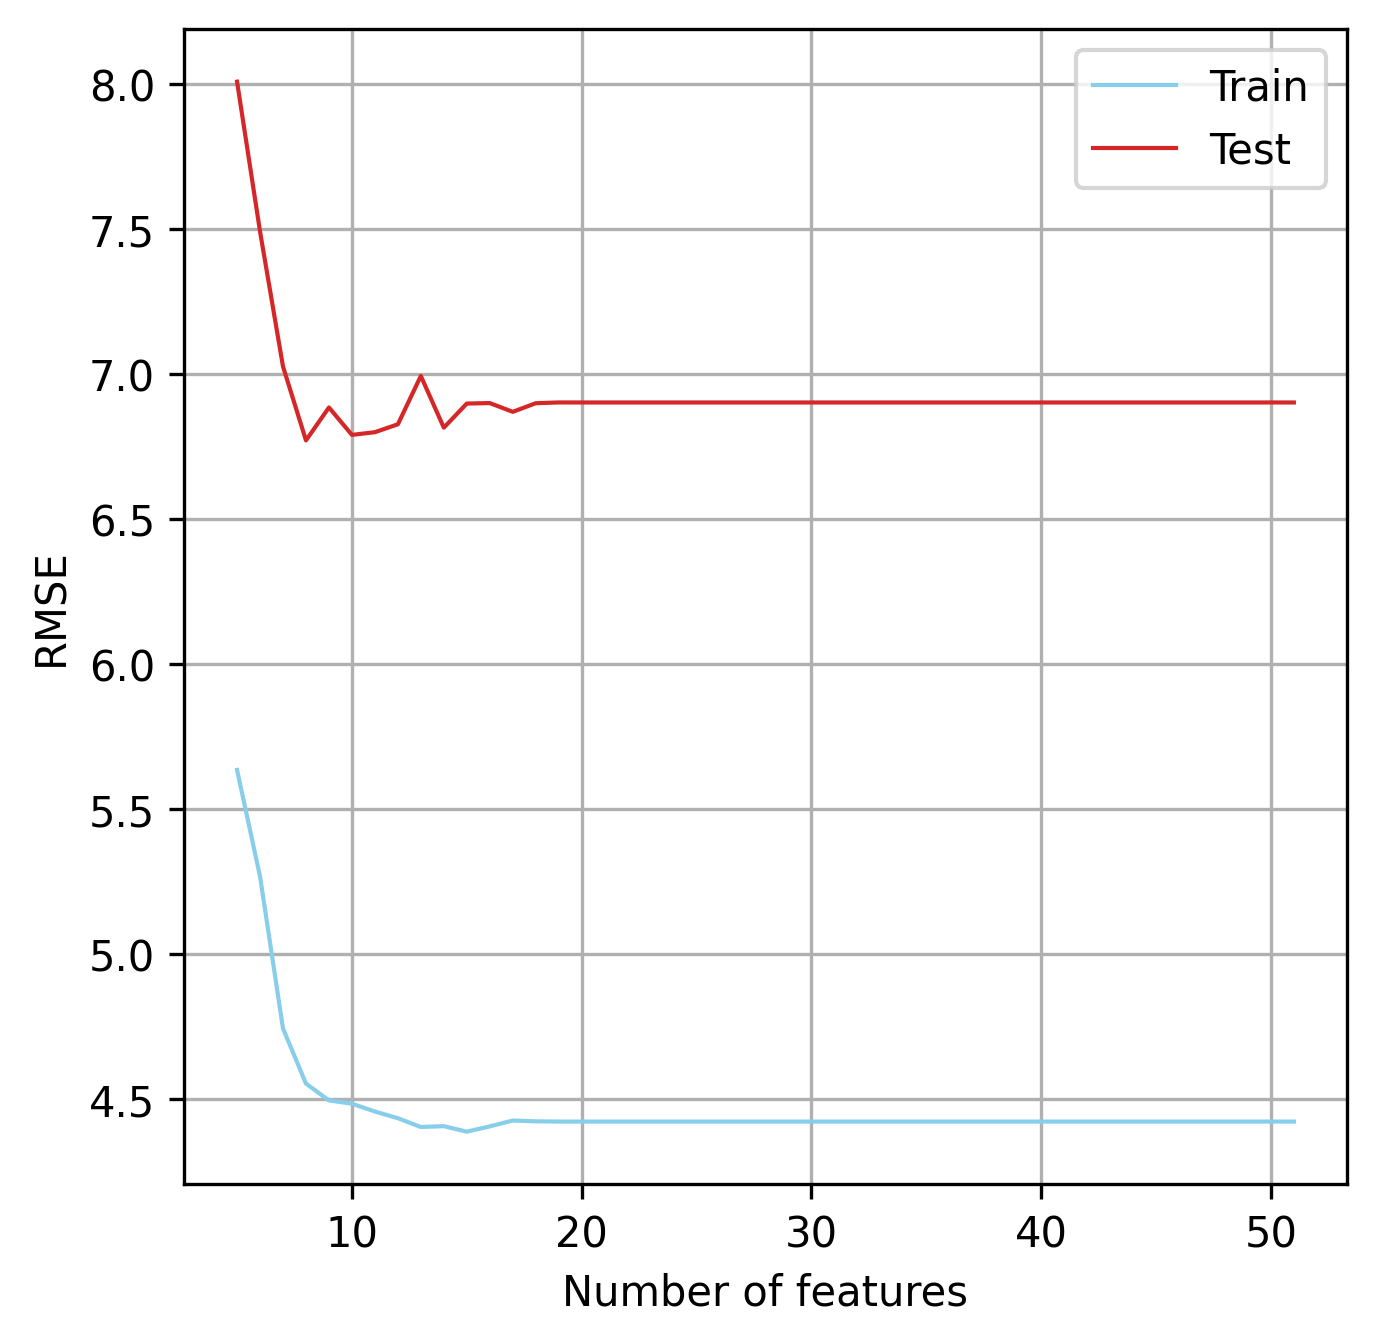

In [24]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    df_train_val_rmse["n_features"],
    df_train_val_rmse[f"{column_target}_rmse"],
    c="skyblue",
    label="Train",
    lw=1
)
ax.plot(
    df_test_rmse["n_features"],
    df_test_rmse[f"{column_target}_rmse"],
    c="tab:red",
    label="Test",
    lw=1
)

ax.set_xlabel("Number of features")
ax.set_ylabel("RMSE")

ax.grid()
ax.legend()

plt.savefig(
    f"{file_write}_plot.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [25]:
df_train_val_min = df_train_val_preds.filter(pl.col("n_features") == n_features_min)

In [26]:
df_train_val_min

pyridone_test,n_features,pyridone,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i64,i64,i64,i64,f64,f64,f64,f64
0,15,1,0,0.56851,0.315216,63.841924,57.815795
0,15,1,1,0.577178,0.508972,64.041771,62.456543
0,15,1,2,0.53889,0.382647,63.155406,59.451129
0,15,1,3,0.85113,0.399792,70.080418,59.863775
0,15,1,4,0.637598,0.440079,65.421028,60.827793
…,…,…,…,…,…,…,…
12,15,11,3,-0.486342,-0.325366,38.07556,41.936855
12,15,11,4,-0.441697,-0.354818,39.133657,41.221457
12,15,11,5,0.134649,-0.104678,53.361149,47.38544


In [27]:
df_test_min = df_test_preds.filter(pl.col("n_features") == n_features_min)

In [28]:
df_test_min

pyridone_test,n_features,backbone,beta_av_logit,beta_av_logit_pred,beta_av,beta_av_pred
i64,i64,i64,f64,f64,f64,f64
0,15,0,0.055549,0.149272,51.388357,53.724892
0,15,1,0.061619,0.040482,51.539999,51.011916
0,15,2,-0.086761,-0.010161,47.832328,49.745977
0,15,3,-0.086245,0.024999,47.845209,50.624935
0,15,4,-0.242775,0.033542,43.960253,50.838483
…,…,…,…,…,…,…
12,15,3,-0.155744,0.075001,46.114252,51.874146
12,15,4,-0.010116,0.071275,49.74711,51.781113
12,15,5,-0.04161,0.327728,48.959898,58.120643


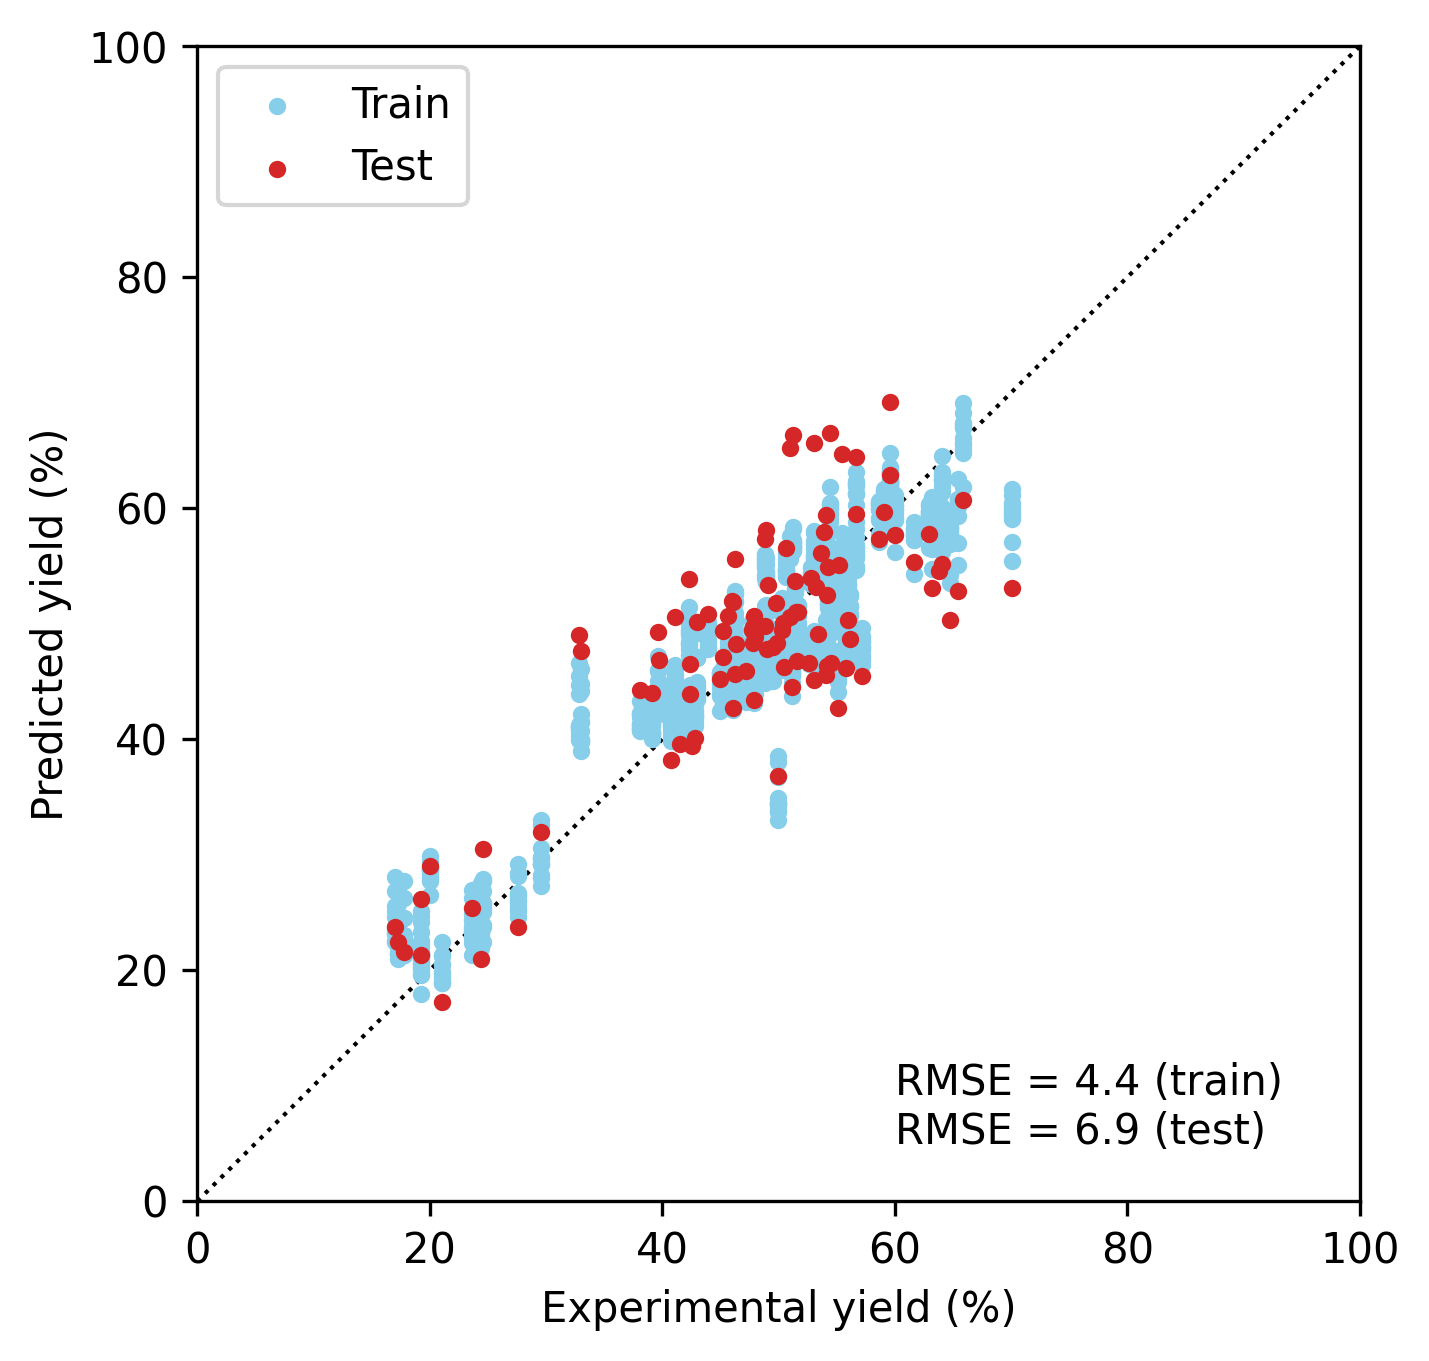

In [29]:
fig, ax = plt.subplots(figsize=(5, 5), dpi=300)

ax.plot(
    [0, 100],
    [0, 100],
    c="black",
    linestyle="dotted",
    lw=1,
    zorder=0
)
ax.scatter(
    df_train_val_min[column_target],
    df_train_val_min[column_pred],
    c="skyblue",
    label="Train",
    s=10,
    zorder=1
)
ax.scatter(
    df_test_min[column_target],
    df_test_min[column_pred],
    c="tab:red",
    label="Test",
    s=10,
    zorder=2
)

ax.set_xlabel("Experimental yield (%)")
ax.set_ylabel("Predicted yield (%)")
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.legend()
ax.text(
    0.60, 0.05,
    f"RMSE = {df_train_val_rmse_min[f'{column_target}_rmse'][0]:1.1f} (train)\n"
    f"RMSE = {df_test_rmse_min[f'{column_target}_rmse'][0]:1.1f} (test)",
    transform=ax.transAxes
)

plt.savefig(
    f"{file_write}_scatter_all.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()

In [30]:
column_group = "pyridone"

In [31]:
groups_test = df_test_preds[f"{column_group}_test"].unique(maintain_order=True)

In [32]:
groups_test

pyridone_test
i64
0
1
2
3
4
…
8
9
10


In [33]:
df_train_val_min_rmse = (
    df_train_val_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [34]:
df_train_val_min_rmse

pyridone_test,beta_av_rmse
i64,f64
0,4.157082
1,4.415058
2,5.134914
3,3.582466
4,4.221683
…,…
8,4.478955
9,5.279172
10,4.205734


In [35]:
df_test_min_rmse = (
    df_test_min
    .group_by(f"{column_group}_test", maintain_order=True)
    .agg(
        (pl.col(column_target) - pl.col(column_pred)).pow(2).mean().sqrt()
        .alias(f"{column_target}_rmse")
    )
)

In [36]:
df_test_min_rmse

pyridone_test,beta_av_rmse
i64,f64
0,3.842068
1,11.340221
2,3.504072
3,11.9838
4,5.708968
…,…
8,6.904462
9,6.598882
10,4.122388


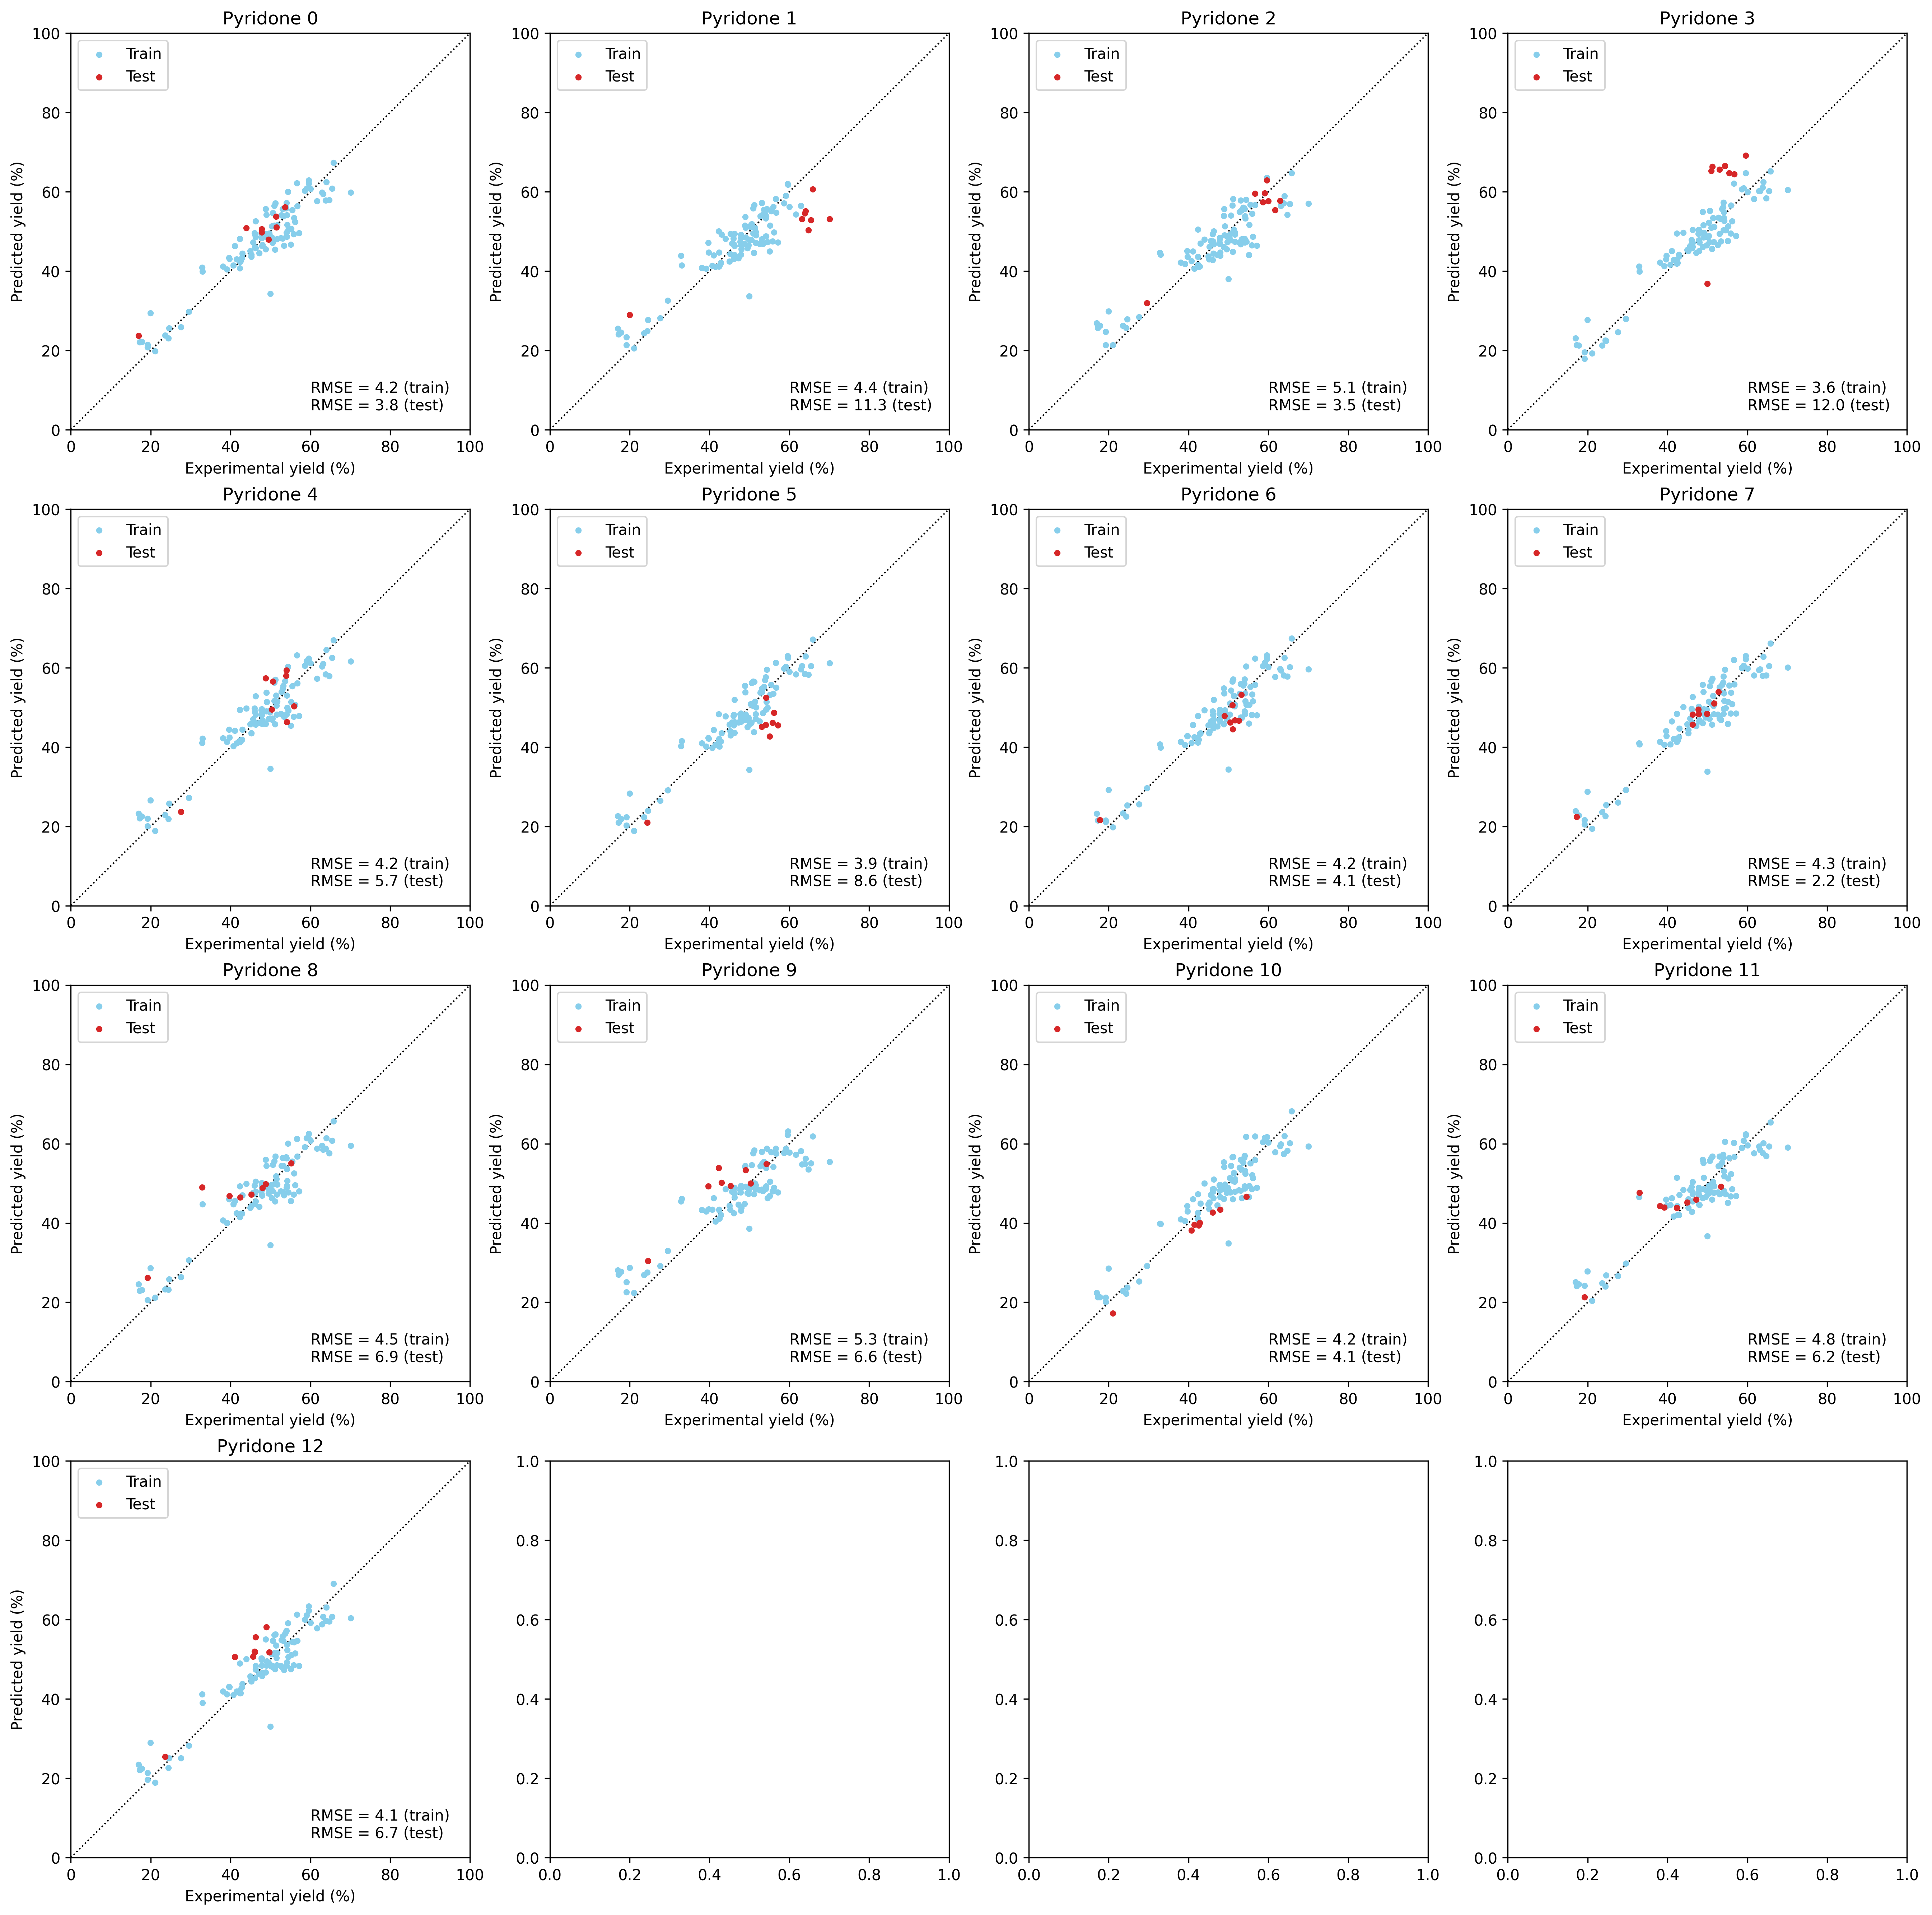

In [37]:
fig, axes = plt.subplots(4, 4, figsize=(22, 22), dpi=300)

for group_test in groups_test:
    df_train_val_min_ = df_train_val_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_ = df_test_min.filter(pl.col(f'{column_group}_test') == group_test)
    df_train_val_min_rmse_ = df_train_val_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    df_test_min_rmse_ = df_test_min_rmse.filter(pl.col(f'{column_group}_test') == group_test)
    
    div, mod = divmod(group_test, 4)
    
    axes[div, mod].plot(
        [0, 100],
        [0, 100],
        c="black",
        linestyle="dotted",
        lw=1,
        zorder=0
    )
    axes[div, mod].scatter(
        df_train_val_min_[column_target],
        df_train_val_min_[column_pred],
        c="skyblue",
        s=10,
        label="Train",
        zorder=1
    )
    axes[div, mod].scatter(
        df_test_min_[column_target],
        df_test_min_[column_pred],
        c="tab:red",
        s=10,
        label="Test",
        zorder=2
    )
    
    axes[div, mod].set_title(f"Pyridone {group_test}")
    axes[div, mod].set_xlabel("Experimental yield (%)")
    axes[div, mod].set_ylabel("Predicted yield (%)")
    axes[div, mod].set_xlim(0, 100)
    axes[div, mod].set_ylim(0, 100)
    
    axes[div, mod].legend()
    axes[div, mod].text(
        0.60, 0.05,
        f"RMSE = {df_train_val_min_rmse_[f'{column_target}_rmse'][0]:1.1f} (train)\n"
        f"RMSE = {df_test_min_rmse_[f'{column_target}_rmse'][0]:1.1f} (test)",
        transform=axes[div, mod].transAxes
    )
    
plt.savefig(
    f"{file_write}_scatter_each.png",
    transparent=True,
    bbox_inches="tight",
    pad_inches=0.1
)
plt.show()